In [12]:
# ============================================================
# CELL 0 — GLOBAL IMPORTS + PATH DETECTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.full as si
import os
from pathlib import Path
import json
import pandas as pd

# ============================================================
# USER INPUT: ONLY EDIT THESE PATHS
# ============================================================
kilosort_path = Path(
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4"
)

# Choose which experiment folder to use (e.g., experiment2 → 2)
EXPERIMENT_NUMBER = 2

# ============================================================
# UNIFIED ANALYSIS FOLDER (STATIC, SHARED ACROSS PIPELINES)
# ============================================================

def find_session_root(path):
    """
    Walk upward until we find the 'Record Node XXX' folder.
    """
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent


def build_analysis_folder(session_root):
    """
    Build analysis folder using the known OpenEphys structure:
    session_date / Record Node XXX / experimentY / recordingZ / ...
    """

    # ---- Find experiment folder inside Record Node ----
    experiment_folders = [
        f for f in session_root.iterdir()
        if f.is_dir() and f.name.lower().startswith("experiment")
    ]
    if not experiment_folders:
        raise RuntimeError("No experiment folder found inside Record Node folder")

    # Select experimentN based on user input
    target_exp_name = f"experiment{EXPERIMENT_NUMBER}"
    experiment_folder = None
    for f in experiment_folders:
        if f.name.lower() == target_exp_name.lower():
            experiment_folder = f
            break

    if experiment_folder is None:
        raise RuntimeError(f"Experiment folder '{target_exp_name}' not found inside Record Node")

    print(f"Using experiment folder: {experiment_folder}")

    # ---- Find recording folder inside experiment ----
    recording_folders = [
        f for f in experiment_folder.iterdir()
        if f.is_dir() and f.name.lower().startswith("recording")
    ]
    if not recording_folders:
        raise RuntimeError("No recording folder found inside experiment folder")
    recording_folder = recording_folders[0]
    print(f"Using recording folder: {recording_folder}")

    # ---- Session date folder is parent of Record Node ----
    session_date_folder = session_root.parent

    session_date = session_date_folder.name
    experiment_name = experiment_folder.name
    recording_name = recording_folder.name

    # ---- Build analysis folder ----
    folder_name = f"{session_date}_{experiment_name}_{recording_name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)

    # ---- Required subfolders ----
    subfolders = [
        "qc",
        "camera_alignment",
        "dlc_alignment",
        "behavior_ttls",
        "peak_detection",
        "metadata",
        "ttls",
        "spikes"
    ]
    for sf in subfolders:
        (analysis_folder / sf).mkdir(exist_ok=True)

    return analysis_folder


def get_analysis_folder(path_from_any_pipeline):
    session_root = find_session_root(path_from_any_pipeline)
    return build_analysis_folder(session_root)

# ============================================================
# AUTO-INCREMENTING FILE SAVE + LATEST-LOAD HELPERS
# ============================================================

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)

    # Try base_name.npy first
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path

    # Otherwise increment
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1


def load_latest(folder, base_name):
    folder = Path(folder)
    candidates = list(folder.glob(f"{base_name}*.npy"))
    if not candidates:
        raise FileNotFoundError(f"No files matching {base_name} in {folder}")
    latest = sorted(candidates, key=lambda p: p.stem)[-1]
    return np.load(latest, allow_pickle=True)

# ============================================================
# RUN FOLDER CREATION + PRINT EVERYTHING
# ============================================================

print("\n===== ANALYSIS FOLDER CREATION =====")

session_root = find_session_root(kilosort_path)
print(f"Session root (Record Node folder): {session_root}")

analysis_folder = get_analysis_folder(kilosort_path)
print(f"Analysis folder created at: {analysis_folder}")

print("\nSubfolders inside analysis folder:")
for f in analysis_folder.iterdir():
    print("  -", f.name)

print("\n===== FOLDER SETUP COMPLETE =====\n")


===== ANALYSIS FOLDER CREATION =====
Session root (Record Node folder): G:\Kevin\2026-03-09_14-29-25\Record Node 114
Using experiment folder: G:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2
Using recording folder: G:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1
Analysis folder created at: G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis

Subfolders inside analysis folder:
  - qc
  - camera_alignment
  - dlc_alignment
  - behavior_ttls
  - peak_detection
  - metadata
  - ttls
  - spikes

===== FOLDER SETUP COMPLETE =====



In [14]:
# ============================================================
# CELL 1 — VERIFY + LOAD RECORDING
# ============================================================

print("\n=== CELL 1 — VERIFY + LOAD RECORDING ===")

# ------------------------------------------------------------
# 1. Resolve session_root (Record Node folder)
# ------------------------------------------------------------
session_root = find_session_root(kilosort_path)
print(f"Session root (Record Node folder): {session_root}")

# ------------------------------------------------------------
# 2. Detect experiment folder using EXPERIMENT_NUMBER
# ------------------------------------------------------------
experiment_folders = [
    f for f in session_root.iterdir()
    if f.is_dir() and f.name.lower().startswith("experiment")
]

if not experiment_folders:
    raise RuntimeError("No experiment folders found inside Record Node folder")

target_exp_name = f"experiment{EXPERIMENT_NUMBER}".lower()

experiment_folder = None
for f in experiment_folders:
    if f.name.lower() == target_exp_name:
        experiment_folder = f
        break

if experiment_folder is None:
    raise RuntimeError(f"Experiment folder '{target_exp_name}' not found inside Record Node")

experiment_name = experiment_folder.name
print(f"Using experiment folder: {experiment_folder}")

# ------------------------------------------------------------
# 3. Detect recording folder inside selected experiment
# ------------------------------------------------------------
recording_folders = [
    f for f in experiment_folder.iterdir()
    if f.is_dir() and f.name.lower().startswith("recording")
]

if not recording_folders:
    raise RuntimeError("No recording folder found inside experiment folder")

recording_folder = recording_folders[0]
print(f"Using recording folder: {recording_folder}")

# ------------------------------------------------------------
# 4. raw_data_path = session_root (Record Node folder)
# ------------------------------------------------------------
raw_data_path = session_root
print(f"raw_data_path set to: {raw_data_path}")
print("Session folder exists:", raw_data_path.is_dir())

# ------------------------------------------------------------
# 5. List record nodes
# ------------------------------------------------------------
record_nodes = [f for f in os.listdir(raw_data_path) if "Record Node" in f]
print("Record Nodes found:", record_nodes)

# ------------------------------------------------------------
# 6. Check structure.oebin
# ------------------------------------------------------------
oebin_path = recording_folder / "structure.oebin"
print(f"Checking {oebin_path}: exists =", oebin_path.is_file())

# ------------------------------------------------------------
# 7. Load Neuropixels stream
# ------------------------------------------------------------
print(f"\nLoading Neuropixels stream from experiment '{experiment_name}'...")

recording = si.read_openephys(
    raw_data_path,
    experiment_name=experiment_name,
    stream_id='1'   # you set this
)
recording = si.scale(recording)

print("\nLoaded recording:")
print(recording)
print("Sampling rate:", recording.sampling_frequency)
print("Num channels:", recording.get_num_channels())

print("\n=== CELL 1 COMPLETE ===\n")


=== CELL 1 — VERIFY + LOAD RECORDING ===
Session root (Record Node folder): G:\Kevin\2026-03-09_14-29-25\Record Node 114
Using experiment folder: G:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2
Using recording folder: G:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1
raw_data_path set to: G:\Kevin\2026-03-09_14-29-25\Record Node 114
Session folder exists: True
Record Nodes found: []
Checking G:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\structure.oebin: exists = True

Loading Neuropixels stream from experiment 'experiment2'...

Loaded recording:
ScaleRecording: 384 channels - 30.0kHz - 1 segments - 59,759,976 samples 
                1,992.00s (33.20 minutes) - float32 dtype - 85.49 GiB
Sampling rate: 30000.0
Num channels: 384

=== CELL 1 COMPLETE ===



In [15]:
# ============================================================
# CELL 2 — CREATE ANALYZER + FEATURE EXTRACTION (run once)
# ============================================================

print("\n=== CELL 2 — CREATE ANALYZER + FEATURE EXTRACTION ===")

# ------------------------------------------------------------
# 1. Define analyzer_path inside the unified analysis folder
# ------------------------------------------------------------
analyzer_path = analysis_folder / "qc" / "sorting_analyzer"
analyzer_path.mkdir(exist_ok=True)
print(f"Analyzer folder set to: {analyzer_path}")

# ------------------------------------------------------------
# 2. Load Kilosort sorting
# ------------------------------------------------------------
print("Loading sorting from kilosort_path...")
sorting = si.read_kilosort(kilosort_path)
print("Sorting loaded.")

# ------------------------------------------------------------
# 3. Create analyzer
# ------------------------------------------------------------
print("Creating analyzer...")

analyzer = si.create_sorting_analyzer(
    sorting=sorting,
    recording=recording,
    folder=analyzer_path,
    format="binary_folder",
    overwrite=True
)

print("Analyzer created.")

# ------------------------------------------------------------
# 4. Compute features (run once)
# ------------------------------------------------------------
print("Computing FEATURES (run once)...")

analyzer.compute("random_spikes", max_spikes_per_unit=300)
print("  - random_spikes computed")

analyzer.compute("waveforms", ms_before=1.0, ms_after=2.0)
print("  - waveforms computed")

analyzer.compute("noise_levels")
print("  - noise_levels computed")

print("\nFeature extraction complete and cached.")
print("=== CELL 2 COMPLETE ===\n")


=== CELL 2 — CREATE ANALYZER + FEATURE EXTRACTION ===
Analyzer folder set to: G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\qc\sorting_analyzer
Loading sorting from kilosort_path...
Sorting loaded.
Creating analyzer...


estimate_sparsity (no parallelization): 100%|██████████████████████████████████████| 1992/1992 [05:34<00:00,  5.96it/s]


Analyzer created.
Computing FEATURES (run once)...
  - random_spikes computed


compute_waveforms (no parallelization): 100%|██████████████████████████████████████| 1992/1992 [08:02<00:00,  4.13it/s]


  - waveforms computed


noise_level (no parallelization): 100%|████████████████████████████████████████████████| 20/20 [00:03<00:00,  5.43it/s]

  - noise_levels computed

Feature extraction complete and cached.
=== CELL 2 COMPLETE ===



In [18]:
# ============================================================
# CELL 3 — LOAD CACHED FEATURES (KILOSORT TEMPLATES ONLY)
# ============================================================

print("\n=== CELL 3 — LOAD CACHED FEATURES ===")

# ------------------------------------------------------------
# 1. Safety checks
# ------------------------------------------------------------
if "analysis_folder" not in globals():
    raise RuntimeError("analysis_folder is not defined. Run CELL 0 first.")

if "recording" not in globals():
    raise RuntimeError("recording is not defined. Run CELL 1 first.")

# Analyzer folder (created in CELL 2)
analyzer_path = analysis_folder / "qc" / "sorting_analyzer"
print(f"Analyzer folder: {analyzer_path}")

if not analyzer_path.exists():
    raise RuntimeError("Analyzer folder does not exist. Run CELL 2 first.")

# ------------------------------------------------------------
# 2. Reload analyzer from disk
# ------------------------------------------------------------
print("Reloading analyzer from cached folder...")

analyzer = si.load_sorting_analyzer(analyzer_path)
print("Analyzer loaded from disk.")

# ------------------------------------------------------------
# 3. Load SI extensions (waveforms + noise)
# ------------------------------------------------------------
try:
    wfs_ext = analyzer.get_extension("waveforms")
    noise_ext = analyzer.get_extension("noise_levels")
except Exception as e:
    raise RuntimeError(f"ERROR: Failed to load one or more extensions: {e}")

# Extract noise levels
try:
    noise = noise_ext.get_data()
except Exception as e:
    raise RuntimeError(f"ERROR: Failed to extract noise data: {e}")

print("Loaded SI cached features.")

# ============================================================
# LOAD KILOSORT TEMPLATES + CHANNEL MAP + PHY CLUSTER INFO
# ============================================================

ks_templates = np.load(kilosort_path / "templates.npy")
ks_channel_map = np.load(kilosort_path / "channel_map.npy")
cluster_info = pd.read_csv(kilosort_path / "cluster_info.tsv", sep="\t")

print("\n=== FEATURE LOAD SUMMARY ===")
print("Kilosort templates shape:", ks_templates.shape)
print("Noise array shape:", noise.shape)
print("Number of units:", len(sorting.unit_ids))

# Build mapping: unit_id → Phy main channel ID
cluster_col = "cluster_id" if "cluster_id" in cluster_info.columns else "id"
channel_col = "ch" if "ch" in cluster_info.columns else "channel"

phy_best_ch_id = {
    int(row[cluster_col]): int(row[channel_col])
    for _, row in cluster_info.iterrows()
}

# ============================================================
# UNWHITEN KILOSORT TEMPLATES
# ============================================================

whitening_inv = np.load(kilosort_path / "whitening_mat_inv.npy")

ks_templates_unwhitened = np.einsum("ij,utj->uti", whitening_inv, ks_templates)

print("Unwhitened templates shape:", ks_templates_unwhitened.shape)

phys_to_template_index = {phys_id: idx for idx, phys_id in enumerate(ks_channel_map)}

print("\nAll features loaded successfully ✔️")
print("=== CELL 3 COMPLETE ===\n")


=== CELL 3 — LOAD CACHED FEATURES ===
Analyzer folder: G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\qc\sorting_analyzer
Reloading analyzer from cached folder...
Analyzer loaded from disk.
Loaded SI cached features.

=== FEATURE LOAD SUMMARY ===
Kilosort templates shape: (437, 61, 384)
Noise array shape: (384,)
Number of units: 437
Unwhitened templates shape: (437, 61, 384)

All features loaded successfully ✔️
=== CELL 3 COMPLETE ===




=== CELL 4 — AMPLITUDE QC ===
Computing amplitudes for each unit...
Amplitude extraction complete.
Using amplitude cutoff: 1770 µV


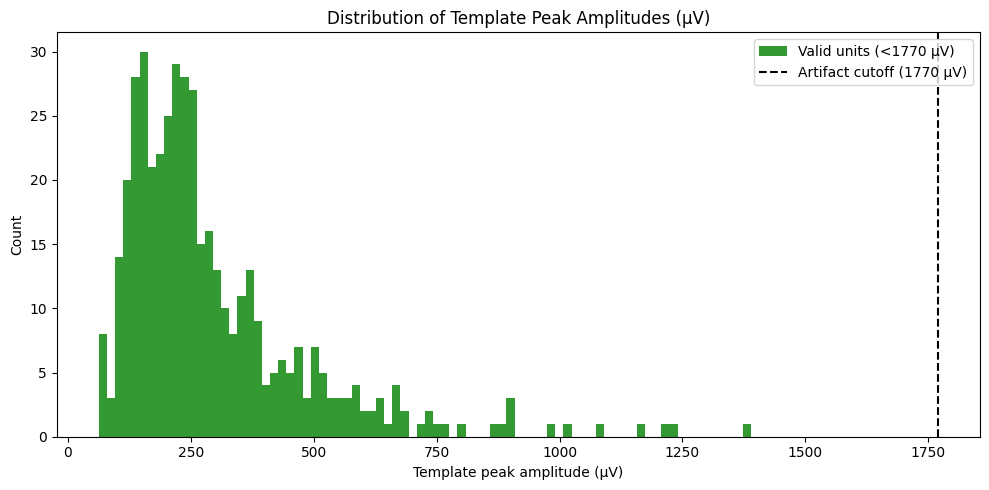


=== AMPLITUDE DISTRIBUTION SUMMARY ===
Total units: 437
Valid units (<1770 µV): 437
Artifact units (≥1770 µV): 0
Median amplitude (valid units): 239.95 µV
Max amplitude (valid units): 1389.26 µV

Artifact units (first 20): [] 

Amplitude QC labels generated.
=== CELL 4 COMPLETE ===



In [19]:
# ============================================================
# CELL 4 — AMPLITUDE DISTRIBUTION + ARTIFACT UNIT DETECTION (µV)
# ============================================================

print("\n=== CELL 4 — AMPLITUDE QC ===")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["sorting", "ks_templates_unwhitened", "phy_best_ch_id", "phys_to_template_index"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' is missing. Run previous cells first.")

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# COMPUTE UNIT AMPLITUDES (µV) FROM UNWHITENED KS TEMPLATES
# ------------------------------------------------------------
print("Computing amplitudes for each unit...")

unit_amp = {}

for uid in sorting.unit_ids:
    # template index = unit index in Kilosort order
    ks_idx = np.where(sorting.unit_ids == uid)[0][0]

    # get the unwhitened template for this unit
    temp = ks_templates_unwhitened[ks_idx]   # shape (samples, channels)

    # find the best channel from Phy
    best_ch_phys = phy_best_ch_id[uid]
    best_ch_idx = phys_to_template_index[best_ch_phys]

    # amplitude = peak-to-peak on best channel
    waveform = temp[:, best_ch_idx]
    amp_uv = waveform.max() - waveform.min()

    unit_amp[uid] = amp_uv

print("Amplitude extraction complete.")

# ------------------------------------------------------------
# TUNABLE PARAMETER (ONLY EDIT HERE)
# ------------------------------------------------------------
amp_cutoff_uv = 1770
print(f"Using amplitude cutoff: {amp_cutoff_uv} µV")

# ------------------------------------------------------------
# BUILD AMPLITUDE ARRAY
# ------------------------------------------------------------
amps = np.array([unit_amp[uid] for uid in sorting.unit_ids])

artifact_mask = amps >= amp_cutoff_uv
valid_mask = amps < amp_cutoff_uv

amps_valid = amps[valid_mask]
amps_artifact = amps[artifact_mask]

# ------------------------------------------------------------
# PLOT HISTOGRAM
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(amps_valid, bins=80, color='green', alpha=0.8,
         label=f'Valid units (<{amp_cutoff_uv} µV)')
if np.any(artifact_mask):
    plt.hist(amps_artifact, bins=40, color='red', alpha=0.8,
             label=f'Artifact units (≥{amp_cutoff_uv} µV)')

plt.axvline(amp_cutoff_uv, color='black', linestyle='--', linewidth=1.5,
            label=f'Artifact cutoff ({amp_cutoff_uv} µV)')

plt.xlabel("Template peak amplitude (µV)")
plt.ylabel("Count")
plt.title("Distribution of Template Peak Amplitudes (µV)")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# UPDATE ARTIFACT + VALID UNIT LISTS FOR QC PIPELINE
# ------------------------------------------------------------
artifact_units = [uid for uid in sorting.unit_ids if unit_amp[uid] >= amp_cutoff_uv]
valid_units = [uid for uid in sorting.unit_ids if unit_amp[uid] < amp_cutoff_uv]

print("\n=== AMPLITUDE DISTRIBUTION SUMMARY ===")
print(f"Total units: {len(amps)}")
print(f"Valid units (<{amp_cutoff_uv} µV): {len(valid_units)}")
print(f"Artifact units (≥{amp_cutoff_uv} µV): {len(artifact_units)}")
print(f"Median amplitude (valid units): {np.median(amps_valid):.2f} µV")
print(f"Max amplitude (valid units): {np.max(amps_valid):.2f} µV")

print("\nArtifact units (first 20):", artifact_units[:20], 
      "..." if len(artifact_units) > 20 else "")

# ------------------------------------------------------------
# MODULE OUTPUT: AMPLITUDE QC LABELS
# ------------------------------------------------------------
qc_amp = {}
for uid in sorting.unit_ids:
    qc_amp[uid] = "FAIL_AMP" if uid in artifact_units else "PASS_AMP"

print("\nAmplitude QC labels generated.")
print("=== CELL 4 COMPLETE ===\n")

In [20]:
# ============================================================
# PHY "Amplitude" FILTER USING cluster_info.tsv
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# TUNABLE PARAMETER (ONLY EDIT HERE)
# ------------------------------------------------------------
phy_amp_cutoff = 10  ######################################################################################################################################################################################################################################################################
# ↑↑↑ Kevin edits this ONE value. Everything else depends on it.

# ------------------------------------------------------------
# LOAD PHY CLUSTER INFO
# ------------------------------------------------------------
cluster_info_path = kilosort_path / "cluster_info.tsv"
ci = pd.read_csv(cluster_info_path, sep='\t')

# Build dict: KS cluster id -> Phy "Amplitude" value (the column you circled)
phy_amp_from_info = {
    int(row["id"]): float(row["Amplitude"])
    for _, row in ci.iterrows()
}

# ------------------------------------------------------------
# CLASSIFY UNITS BASED ON PHY AMPLITUDE
# ------------------------------------------------------------
phy_valid_units = [
    uid for uid in sorting.unit_ids
    if phy_amp_from_info.get(int(uid), 0.0) >= phy_amp_cutoff
]

phy_artifact_units = [
    uid for uid in sorting.unit_ids
    if phy_amp_from_info.get(int(uid), 0.0) < phy_amp_cutoff
]

print("\n=== PHY Amplitude FILTER (from cluster_info.tsv) ===")
print(f"Valid units (Amplitude >= {phy_amp_cutoff}): {len(phy_valid_units)}")
print(f"Artifact units (Amplitude < {phy_amp_cutoff}): {len(phy_artifact_units)}")

# ------------------------------------------------------------
# MODULE OUTPUT: PHY AMPLITUDE QC LABELS
# ------------------------------------------------------------
qc_phy_amp = {}
for uid in sorting.unit_ids:
    if uid in phy_artifact_units:
        qc_phy_amp[uid] = "FAIL_PHYAMP"
    else:
        qc_phy_amp[uid] = "PASS_PHYAMP"



=== PHY Amplitude FILTER (from cluster_info.tsv) ===
Valid units (Amplitude >= 10): 272
Artifact units (Amplitude < 10): 165


In [21]:
# ============================================================
# UNIFIED SHAPE QC: WIDTH + OSCILLATION (1-of-2 RULE)
# ============================================================

print("\n=== UNIFIED SHAPE QC: WIDTH + OSCILLATION (1-of-2 RULE) ===")

sampling_rate = recording.sampling_frequency  # e.g. 30000 Hz

# ============================================================
# ######################## TUNABLE PARAMETERS #################
# ============================================================

min_width_ms  = 0.1       ########################################################################################################################################################
max_zerox     = 4          ########################################################################################################################################################
window_ms     = 1.5       ########################################################################################################################################################
# min_width_ms  : width below this → fail
# max_zerox     : zero-crossings above this → fail
# window_ms     : window around trough for oscillation check

# ============================================================
# STORAGE
# ============================================================

unit_width_ms = {}
unit_zerox = {}
shape_artifact_units = []

win_samples = int(window_ms * sampling_rate / 1000)

# ============================================================
# MAIN LOOP
# ============================================================

for i, uid in enumerate(sorting.unit_ids):

    wf = ks_templates_unwhitened[i]  # (samples, channels)

    # --- best channel by negative peak ---
    neg_peaks = -np.min(wf, axis=0)
    best_ch = int(np.argmax(neg_peaks))
    trace = wf[:, best_ch]

    # ============================================================
    # 1. WIDTH (half-minimum)
    # ============================================================
    trough_idx = int(np.argmin(trace))
    trough_val = trace[trough_idx]
    half = trough_val / 2

    below = np.where(trace < half)[0]
    if len(below) == 0:
        width_samples = 0
    else:
        width_samples = below[-1] - below[0]

    width_ms = (width_samples / sampling_rate) * 1000
    unit_width_ms[uid] = width_ms

    # ============================================================
    # 2. OSCILLATION (zero-crossings in window)
    # ============================================================
    start = max(0, trough_idx - win_samples // 2)
    end   = min(len(trace), trough_idx + win_samples // 2)

    seg = trace[start:end] - np.mean(trace[start:end])
    signs = np.sign(seg)
    signs[signs == 0] = 1
    zerox = int(np.sum(signs[1:] != signs[:-1]))
    unit_zerox[uid] = zerox

    # ============================================================
    # 1-of-2 RULE (fail ANY ONE metric → artifact)
    # ============================================================
    fail_width = width_ms < min_width_ms
    fail_osc   = zerox > max_zerox

    if fail_width or fail_osc:
        shape_artifact_units.append(uid)

# ============================================================
# SUMMARY
# ============================================================

print(f"Units flagged by shape QC (≥1 fail): {len(shape_artifact_units)}")
print("Example flagged units:", shape_artifact_units[:10])

# ============================================================
# MODULE OUTPUT: WAVEFORM SHAPE QC LABELS
# ============================================================

qc_wave = {}

for uid in sorting.unit_ids:
    if uid in shape_artifact_units:
        qc_wave[uid] = "FAIL_WAVE"
    else:
        qc_wave[uid] = "PASS_WAVE"




=== UNIFIED SHAPE QC: WIDTH + OSCILLATION (1-of-2 RULE) ===
Units flagged by shape QC (≥1 fail): 4
Example flagged units: [np.int64(28), np.int64(45), np.int64(252), np.int64(320)]


Computing SNR and amplitude QC using Kilosort templates...

=== AMPLITUDE FILTER RESULTS ===
Valid units (< 1770 µV): 437
Artifact units (≥ 1770 µV): 0

=== SNR QC SUMMARY (best channel) ===
Median noise (µV): 27.2917423248291
Median template peak (µV): 170.63319396972656
Median SNR: 6.354492881392632

First 5 units:
Unit 0: best_ch=3, amp=295.8 µV, noise=26.8 µV, SNR=11.04
Unit 1: best_ch=1, amp=191.5 µV, noise=25.6 µV, SNR=7.48
Unit 2: best_ch=2, amp=55.7 µV, noise=26.2 µV, SNR=2.12
Unit 3: best_ch=1, amp=408.1 µV, noise=25.6 µV, SNR=15.93
Unit 4: best_ch=2, amp=306.1 µV, noise=26.2 µV, SNR=11.67


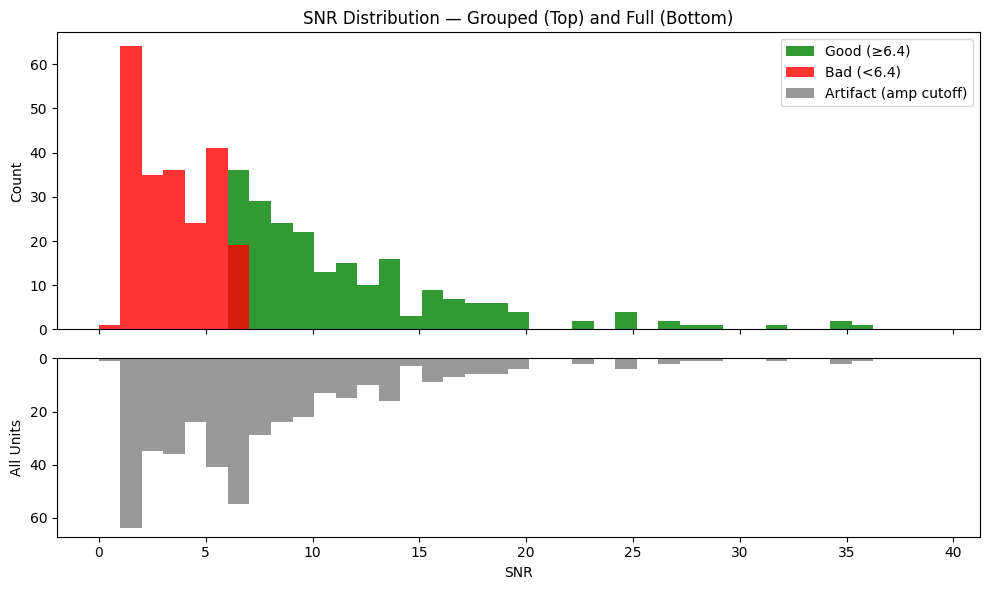

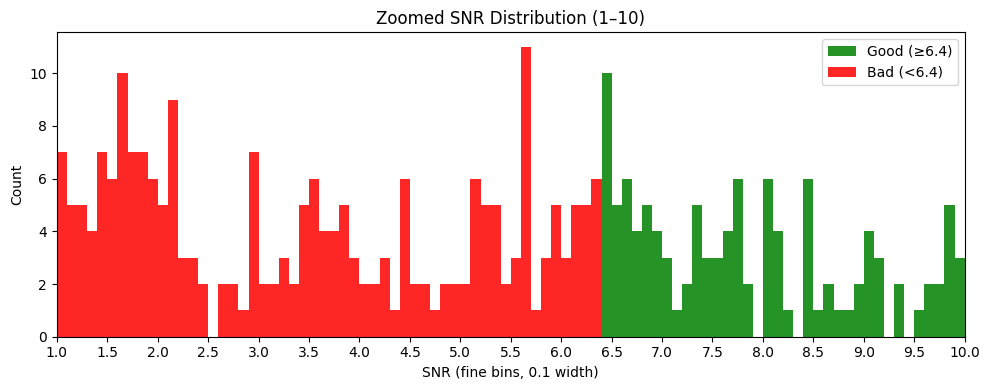


=== 10 UNITS AROUND MEDIAN SNR (median=6.35) ===
Unit 252: SNR=6.22, amp=168.1 µV, noise=27.0 µV, best_ch=245
Unit 7: SNR=6.23, amp=170.6 µV, noise=27.4 µV, best_ch=99
Unit 92: SNR=6.23, amp=168.1 µV, noise=27.0 µV, best_ch=117
Unit 335: SNR=6.31, amp=184.3 µV, noise=29.2 µV, best_ch=169
Unit 274: SNR=6.33, amp=175.0 µV, noise=27.7 µV, best_ch=345
Unit 341: SNR=6.35, amp=163.1 µV, noise=25.7 µV, best_ch=262
Unit 311: SNR=6.36, amp=179.1 µV, noise=28.2 µV, best_ch=353
Unit 5: SNR=6.36, amp=166.8 µV, noise=26.2 µV, best_ch=2
Unit 142: SNR=6.38, amp=173.0 µV, noise=27.1 µV, best_ch=221
Unit 46: SNR=6.40, amp=179.4 µV, noise=28.0 µV, best_ch=106

=== SNR QC CLASSIFICATION ===
SNR good units (≥6.4): 214
SNR bad units (<6.4): 220
Artifact units (amp ≥ 1770 µV): 0

First 5 SNR-good units: [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(8)]
First 5 SNR-bad units: [np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(15)]
First 5 artifact units: []


In [23]:
# ============================================================
# CELL 4 — SNR + TEMPLATE AMPLITUDE QC (KILOSORT TEMPLATES)
# ============================================================

print("Computing SNR and amplitude QC using Kilosort templates...")

# ------------------------------------------------------------
# TUNABLE PARAMETERS (ONLY EDIT THESE)
# ------------------------------------------------------------
amp_cutoff_uv = 1770  ###########################################################################################################################################################################################################
snr_threshold = 6.4 ##############################################################################################################################################################################################################################################################
# ↑↑↑ Kevin edits these ONE TIME. Everything else depends on them.

# ------------------------------------------------------------
# COMPUTE TEMPLATE AMPLITUDE, NOISE, SNR
# ------------------------------------------------------------

unit_best_ch = {}
unit_amp = {}
unit_noise = {}
unit_snr = {}

for i, uid in enumerate(sorting.unit_ids):

    templ = ks_templates_unwhitened[i]    # <-- Kilosort template (unwhitened)

    # Best channel = most negative peak
    neg_peaks = -np.min(templ, axis=0)
    best_ch = int(np.argmax(neg_peaks))
    neg_peak = float(neg_peaks[best_ch])

    # Noise from SI
    noise_best = float(noise[best_ch])
    snr = neg_peak / noise_best if noise_best > 0 else np.nan

    unit_best_ch[uid] = best_ch
    unit_amp[uid] = neg_peak
    unit_noise[uid] = noise_best
    unit_snr[uid] = snr

# ------------------------------------------------------------
# FILTER ARTIFACT UNITS BY TEMPLATE AMPLITUDE
# ------------------------------------------------------------

valid_units = [uid for uid in sorting.unit_ids if unit_amp[uid] < amp_cutoff_uv]
artifact_units = [uid for uid in sorting.unit_ids if unit_amp[uid] >= amp_cutoff_uv]

print("\n=== AMPLITUDE FILTER RESULTS ===")
print(f"Valid units (< {amp_cutoff_uv} µV): {len(valid_units)}")
print(f"Artifact units (≥ {amp_cutoff_uv} µV): {len(artifact_units)}")

# ------------------------------------------------------------
# SUMMARY STATISTICS
# ------------------------------------------------------------

amps_all = np.array(list(unit_amp.values()))
snrs_all = np.array(list(unit_snr.values()))
noise_all = np.array(list(unit_noise.values()))

print("\n=== SNR QC SUMMARY (best channel) ===")
print("Median noise (µV):", float(np.median(noise_all)))
print("Median template peak (µV):", float(np.median(amps_all)))
print("Median SNR:", float(np.nanmedian(snrs_all)))

print("\nFirst 5 units:")
for uid in sorting.unit_ids[:5]:
    print(f"Unit {uid}: best_ch={unit_best_ch[uid]}, amp={unit_amp[uid]:.1f} µV, "
          f"noise={unit_noise[uid]:.1f} µV, SNR={unit_snr[uid]:.2f}")

# ------------------------------------------------------------
# TWO-PART SNR HISTOGRAM
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

snr_good = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] >= snr_threshold])
snr_bad  = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] <  snr_threshold])
snr_artifact = np.array([unit_snr[uid] for uid in artifact_units])

snr_all = np.array([unit_snr[uid] for uid in sorting.unit_ids])

bins = np.linspace(0, max(snr_all) * 1.1, 40)

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 0.6]}
)

ax_top.hist(snr_good, bins=bins, color='green', alpha=0.8, label=f'Good (≥{snr_threshold})')
ax_top.hist(snr_bad,  bins=bins, color='red',   alpha=0.8, label=f'Bad (<{snr_threshold})')
ax_top.hist(snr_artifact, bins=bins, color='gray', alpha=0.8, label='Artifact (amp cutoff)')

ax_top.set_ylabel("Count")
ax_top.set_title("SNR Distribution — Grouped (Top) and Full (Bottom)")
ax_top.legend(loc='upper right')

ax_bottom.hist(snr_all, bins=bins, color='black', alpha=0.4)
ax_bottom.invert_yaxis()
ax_bottom.set_ylabel("All Units")
ax_bottom.set_xlabel("SNR")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ZOOMED SNR HISTOGRAM (1–10)
# ------------------------------------------------------------

snr_good = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] >= snr_threshold])
snr_bad  = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] <  snr_threshold])

bins = np.arange(1, 10.1, 0.1)

plt.figure(figsize=(10, 4))
plt.hist(snr_good, bins=bins, color='green', alpha=0.85, label=f'Good (≥{snr_threshold})')
plt.hist(snr_bad,  bins=bins, color='red',   alpha=0.85, label=f'Bad (<{snr_threshold})')

plt.xticks(np.arange(1, 11, 0.5))
plt.xlim(1, 10)

plt.xlabel("SNR (fine bins, 0.1 width)")
plt.ylabel("Count")
plt.title("Zoomed SNR Distribution (1–10)")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ============================================================
# UNITS AROUND THE MEDIAN SNR (FIXED: EXCLUDES NaNs)
# ============================================================

around_n = 10  ###############################################################################################################
# ↑↑↑ Kevin-tunable parameter: how many units to print around the median SNR

# Extract SNRs for valid units, excluding NaNs
snr_list = [(uid, unit_snr[uid]) for uid in valid_units if not np.isnan(unit_snr[uid])]
snr_values = np.array([s for _, s in snr_list])

# Compute correct median
median_snr_val = np.median(snr_values)

# Sort by SNR
snr_sorted = sorted(snr_list, key=lambda x: x[1])

# Find index of unit closest to the median
median_idx = min(
    range(len(snr_sorted)),
    key=lambda i: abs(snr_sorted[i][1] - median_snr_val)
)

# Determine slice around the median
start = max(0, median_idx - around_n // 2)
end = min(len(snr_sorted), start + around_n)

print(f"\n=== {end - start} UNITS AROUND MEDIAN SNR (median={median_snr_val:.2f}) ===")
for uid, snr_val in snr_sorted[start:end]:
    print(
        f"Unit {uid}: "
        f"SNR={snr_val:.2f}, "
        f"amp={unit_amp[uid]:.1f} µV, "
        f"noise={unit_noise[uid]:.1f} µV, "
        f"best_ch={unit_best_ch[uid]}"
    )

# ------------------------------------------------------------
# CLASSIFY UNITS BY SNR (USING snr_threshold)
# ------------------------------------------------------------

snr_good_units = [uid for uid in valid_units if unit_snr[uid] >= snr_threshold]
snr_bad_units  = [uid for uid in valid_units if unit_snr[uid] <  snr_threshold]

print("\n=== SNR QC CLASSIFICATION ===")
print(f"SNR good units (≥{snr_threshold}): {len(snr_good_units)}")
print(f"SNR bad units (<{snr_threshold}): {len(snr_bad_units)}")
print(f"Artifact units (amp ≥ {amp_cutoff_uv} µV): {len(artifact_units)}")

print("\nFirst 5 SNR-good units:", snr_good_units[:5])
print("First 5 SNR-bad units:", snr_bad_units[:5])
print("First 5 artifact units:", artifact_units[:5])

# ------------------------------------------------------------
# MODULE OUTPUT: SNR QC LABELS
# ------------------------------------------------------------

qc_snr = {}

for uid in sorting.unit_ids:
    if uid in artifact_units:
        qc_snr[uid] = "SKIP_SNR_ARTIFACT"
    elif uid in snr_good_units:
        qc_snr[uid] = "PASS_SNR"
    else:
        qc_snr[uid] = "FAIL_SNR"


In [24]:
# ============================================================
# CELL 4.5 — POSITIVE DEFLECTION QC (KILOSORT TEMPLATES ONLY)
# ============================================================

print("Computing positive deflection QC using Kilosort templates...")

# ------------------------------------------------------------
# TUNABLE PARAMETER (ONLY EDIT HERE)
# ------------------------------------------------------------
pos_ratio_threshold = 0.4  ################################################################################################################################################################################################################################################
# Increasing this value makes the QC MORE lenient (allows larger positive bumps).
# Decreasing this value makes the QC MORE strict (flags more units as FAIL_POS).
# Interpretation:
#   pos/neg ratio = 0.0 → perfectly negative spike (ideal)
#   pos/neg ratio = 0.3 → small positive bump (usually fine)
#   pos/neg ratio = 0.5 → moderate positive bump (borderline)
#   pos/neg ratio > 0.5 → large positive bump (often artifact)

# ------------------------------------------------------------
# COMPUTE POSITIVE / NEGATIVE PEAK RATIOS
# ------------------------------------------------------------

unit_pos_ratio = {}
unit_pos_amp = {}
unit_neg_amp = {}

for uid in sorting.unit_ids:

    main_ch_id = phy_best_ch_id[uid]

    if main_ch_id not in phys_to_template_index:
        unit_pos_ratio[uid] = np.inf
        unit_pos_amp[uid] = 0.0
        unit_neg_amp[uid] = 0.0
        continue

    main_idx = phys_to_template_index[main_ch_id]
    trace = ks_templates[uid][:, main_idx]

    neg = abs(np.min(trace))
    pos = abs(np.max(trace))

    unit_neg_amp[uid] = float(neg)
    unit_pos_amp[uid] = float(pos)
    unit_pos_ratio[uid] = float(pos / neg) if neg > 0 else np.inf

# ------------------------------------------------------------
# CLASSIFY UNITS BASED ON POSITIVE BUMP RATIO
# ------------------------------------------------------------

pos_bad_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] >= pos_ratio_threshold]
pos_good_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] <  pos_ratio_threshold]

print("\n=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===")
print(f"BAD units (pos/neg >= {pos_ratio_threshold}): {len(pos_bad_units)}")
print(f"GOOD units (pos/neg <  {pos_ratio_threshold}): {len(pos_good_units)}")

# ------------------------------------------------------------
# MODULE OUTPUT: POSITIVE BUMP QC LABELS
# ------------------------------------------------------------

qc_pos = {}
for uid in sorting.unit_ids:
    qc_pos[uid] = "FAIL_POS" if uid in pos_bad_units else "PASS_POS"
# ------------------------------------------------------------
# PRINT EXAMPLE FAILED UNITS (UP TO 15)
# ------------------------------------------------------------

print("\nExample FAILED units (up to 15):")
if len(pos_bad_units) == 0:
    print("None")
else:
    print(pos_bad_units[:15])


Computing positive deflection QC using Kilosort templates...

=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===
BAD units (pos/neg >= 0.4): 157
GOOD units (pos/neg <  0.4): 280

Example FAILED units (up to 15):
[np.int64(2), np.int64(10), np.int64(15), np.int64(18), np.int64(24), np.int64(25), np.int64(26), np.int64(28), np.int64(30), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(45)]


In [25]:
# ============================================================
# CELL 5 — SLIM + SAFE ISI + ACG QC
# ============================================================

import numpy as np

print("Computing ISI violations + ACG (memory‑safe)...")

# ------------------------------------------------------------
# TUNABLE PARAMETERS (ONLY EDIT THESE)
# ------------------------------------------------------------
rp_ms = 2             #####################################################################################################################################################################################################################################################################
isi_threshold = 0.01     #####################################################################################################################################################################################################################################################################
# ↑↑↑ Kevin edits these ONE TIME. Everything else depends on them.

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------
isi_metrics = {}
acg_metrics = {}

# ------------------------------------------------------------
# FUNCTIONS
# ------------------------------------------------------------
def compute_rpv(st_sec, rp_ms=1.0):
    if st_sec.size < 2:
        return np.nan
    isis = np.diff(st_sec)
    return np.sum(isis < (rp_ms / 1000.0)) / len(isis)

def compute_acg(st_sec, bin_ms=1.0, max_lag_ms=50.0):
    if st_sec.size < 2:
        return np.array([0.0]), np.array([0])

    t_ms = st_sec * 1000.0
    diffs = []
    j0 = 0

    for i in range(len(t_ms)):
        t0 = t_ms[i]

        while j0 < len(t_ms) and t_ms[j0] < t0 - max_lag_ms:
            j0 += 1

        j = j0
        while j < len(t_ms) and t_ms[j] <= t0 + max_lag_ms:
            dt = t_ms[j] - t0
            if dt != 0:
                diffs.append(dt)
            j += 1

    diffs = np.array(diffs)
    bins = np.arange(-max_lag_ms, max_lag_ms + bin_ms, bin_ms)
    acg_counts, edges = np.histogram(diffs, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2.0
    return centers, acg_counts

# ------------------------------------------------------------
# LOOP THROUGH UNITS
# ------------------------------------------------------------
fs = recording.sampling_frequency

for uid in sorting.unit_ids:

    if uid in artifact_units:
        continue

    st_samples = sorting.get_unit_spike_train(uid)
    if st_samples.size < 2:
        isi_metrics[uid] = np.nan
        acg_metrics[uid] = (np.array([0]), np.array([0]))
        continue

    st_sec = st_samples / fs

    rpv = compute_rpv(st_sec, rp_ms=rp_ms)
    isi_metrics[uid] = rpv

    acg_x, acg_y = compute_acg(st_sec)
    acg_metrics[uid] = (acg_x, acg_y)

# ------------------------------------------------------------
# CLASSIFICATION
# ------------------------------------------------------------
good_isi_units = [uid for uid in isi_metrics if isi_metrics[uid] <  isi_threshold]
bad_isi_units  = [uid for uid in isi_metrics if isi_metrics[uid] >= isi_threshold]

print("\n=== ISI QC SUMMARY ===")
print(f"Good ISI units (<{isi_threshold*100:.1f}% RPV): {len(good_isi_units)}")
print(f"Bad ISI units (≥{isi_threshold*100:.1f}% RPV): {len(bad_isi_units)}")

print("\nFirst 5 ISI metrics:")
for uid in list(isi_metrics.keys())[:5]:
    print(f"Unit {uid}: RPV={isi_metrics[uid]:.4f}")

# ------------------------------------------------------------
# MODULE OUTPUT: ISI QC LABELS
# ------------------------------------------------------------
qc_isi = {}
for uid in sorting.unit_ids:
    if uid not in isi_metrics:
        qc_isi[uid] = "SKIP_ISI"
    elif np.isnan(isi_metrics[uid]):
        qc_isi[uid] = "SKIP_ISI"
    elif isi_metrics[uid] < isi_threshold:
        qc_isi[uid] = "PASS_ISI"
    else:
        qc_isi[uid] = "FAIL_ISI"


Computing ISI violations + ACG (memory‑safe)...

=== ISI QC SUMMARY ===
Good ISI units (<1.0% RPV): 256
Bad ISI units (≥1.0% RPV): 181

First 5 ISI metrics:
Unit 0: RPV=0.0001
Unit 1: RPV=0.0052
Unit 2: RPV=0.0044
Unit 3: RPV=0.0007
Unit 4: RPV=0.0003


In [26]:
# ============================================================
# FINAL QC TABLE + VERDICT (MODULAR)
# ============================================================

import pandas as pd

qc_rows = []

for uid in sorting.unit_ids:

    # Pull module labels
    amp_label     = qc_amp.get(uid, "NA_AMP")
    phy_label     = qc_phy_amp.get(uid, "NA_PHYAMP")
    snr_label     = qc_snr.get(uid, "NA_SNR")
    isi_label     = qc_isi.get(uid, "NA_ISI")
    pos_label     = qc_pos.get(uid, "NA_POS")
    wave_label    = qc_wave.get(uid, "NA_WAVE")

    # --------------------------------------------------------
    # AUTO-FAIL 1: PHY amplitude
    # --------------------------------------------------------
    if phy_label == "FAIL_PHYAMP":
        verdict = "REJECT"
        qc_rows.append({
            "unit": uid,
            "AMP": amp_label,
            "PHY_AMP": phy_label,
            "SNR": snr_label,
            "ISI": isi_label,
            "POS": pos_label,
            "WAVE": wave_label,
            "fail_count": "AUTO_FAIL_PHY",
            "verdict": verdict
        })
        continue

    # --------------------------------------------------------
    # AUTO-FAIL 2: POSITIVE DEFLECTION QC
    # --------------------------------------------------------
    if pos_label == "FAIL_POS":
        verdict = "REJECT"
        qc_rows.append({
            "unit": uid,
            "AMP": amp_label,
            "PHY_AMP": phy_label,
            "SNR": snr_label,
            "ISI": isi_label,
            "POS": pos_label,
            "WAVE": wave_label,
            "fail_count": "AUTO_FAIL_POS",
            "verdict": verdict
        })
        continue

    # --------------------------------------------------------
    # NORMAL FAIL-COUNT LOGIC
    # --------------------------------------------------------
    labels = [amp_label, snr_label, isi_label, pos_label, wave_label]
    fail_count = sum(lbl.startswith("FAIL") for lbl in labels)

    if fail_count == 0:
        verdict = "GOOD"
    elif fail_count == 1:
        verdict = "CHECK"
    else:
        verdict = "REJECT"

    qc_rows.append({
        "unit": uid,
        "AMP": amp_label,
        "PHY_AMP": phy_label,
        "SNR": snr_label,
        "ISI": isi_label,
        "POS": pos_label,
        "WAVE": wave_label,
        "fail_count": fail_count,
        "verdict": verdict
    })

# Build DataFrame
qc_df = pd.DataFrame(qc_rows).sort_values("unit").reset_index(drop=True)

print("\n=== FINAL QC VERDICT COUNTS ===")
print(qc_df["verdict"].value_counts())

qc_df.head(20)



=== FINAL QC VERDICT COUNTS ===
verdict
REJECT    219
GOOD      133
CHECK      85
Name: count, dtype: int64


,unit,AMP,PHY_AMP,SNR,ISI,POS,WAVE,fail_count,verdict
0,0,PASS_AMP,PASS_PHYAMP,PASS_SNR,PASS_ISI,PASS_POS,PASS_WAVE,0,GOOD
1,1,PASS_AMP,FAIL_PHYAMP,PASS_SNR,PASS_ISI,PASS_POS,PASS_WAVE,AUTO_FAIL_PHY,REJECT
2,2,PASS_AMP,FAIL_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,PASS_WAVE,AUTO_FAIL_PHY,REJECT
3,3,PASS_AMP,PASS_PHYAMP,PASS_SNR,PASS_ISI,PASS_POS,PASS_WAVE,0,GOOD
4,4,PASS_AMP,PASS_PHYAMP,PASS_SNR,PASS_ISI,PASS_POS,PASS_WAVE,0,GOOD
5,5,PASS_AMP,PASS_PHYAMP,FAIL_SNR,FAIL_ISI,PASS_POS,PASS_WAVE,2,REJECT
6,6,PASS_AMP,PASS_PHYAMP,FAIL_SNR,FAIL_ISI,PASS_POS,PASS_WAVE,2,REJECT
7,7,PASS_AMP,FAIL_PHYAMP,FAIL_SNR,PASS_ISI,PASS_POS,PASS_WAVE,AUTO_FAIL_PHY,REJECT
8,8,PASS_AMP,PASS_PHYAMP,PASS_SNR,FAIL_ISI,PASS_POS,PASS_WAVE,1,CHECK
9,9,PASS_AMP,PASS_PHYAMP,PASS_SNR,FAIL_ISI,PASS_POS,PASS_WAVE,1,CHECK


In [27]:
# ============================================================
# REBUILD cluster_group.tsv FROM QC VERDICTS (CHECK → GOOD)
# ============================================================

import pandas as pd

cluster_group_path = kilosort_path / "cluster_group.tsv"

rows = []

for row in qc_df.itertuples():
    uid = int(row.unit)
    verdict = row.verdict

    # Map QC verdict → Phy label
    if verdict == "REJECT":
        group = "noise"      # Ctrl+N equivalent
    elif verdict == "CHECK":
        group = "good"       # CHECK now treated as GOOD
    elif verdict == "GOOD":
        group = "good"
    else:
        group = "good"

    rows.append({"cluster_id": uid, "group": group})

cg_new = pd.DataFrame(rows)
cg_new.to_csv(cluster_group_path, sep="\t", index=False)

print("Rebuilt cluster_group.tsv with", len(cg_new), "rows.")
print("CHECK units are now labeled as GOOD in Phy.")


Rebuilt cluster_group.tsv with 437 rows.
CHECK units are now labeled as GOOD in Phy.
